# Buzzhive Hybrid Anomaly Detection System

This notebook combines the CNN classifier and VAE anomaly detector:
1. Load both trained models
2. Implement hybrid detection logic
3. End-to-end evaluation on test set
4. Example inference pipeline


In [ ]:
import os
# Enable MPS fallback for unsupported operations
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import librosa

# M2 MPS with fallback
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
OUTPUT_DIR = Path('../outputs')
PROCESSED_DIR = OUTPUT_DIR / 'processed'
MODEL_DIR = OUTPUT_DIR / 'models'
AUDIO_DIR = Path('../archive/sound_files/sound_files')

# Load configuration
with open(PROCESSED_DIR / 'config.json', 'r') as f:
    config_dict = json.load(f)
CLASS_NAMES = {int(k): v for k, v in config_dict['class_names'].items()}


Using device: mps


## 1. Load Models


In [ ]:
# Define model architectures (same as training notebooks)

class BeehiveCNN(nn.Module):
    """CNN classifier for queen status detection."""
    def __init__(self, num_classes=4, dropout=0.3):
        super(BeehiveCNN, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), nn.Dropout2d(dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), nn.Dropout2d(dropout)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), nn.Dropout2d(dropout)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        return self.fc(x)


class ConvVAE(nn.Module):
    """Convolutional VAE for anomaly detection."""
    def __init__(self, input_channels=39, seq_length=431, latent_dim=16):
        super(ConvVAE, self).__init__()
        self.input_channels = input_channels
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(8)
        )
        self.flatten_size = 256 * 8
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.ConvTranspose1d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.final_conv = nn.Conv1d(64, input_channels, kernel_size=1)
        self.final_upsample = nn.Upsample(size=seq_length, mode='linear', align_corners=False)
        
    def encode(self, x):
        h = self.encoder(x).view(-1, self.flatten_size)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std
    
    def decode(self, z):
        h = self.fc_decode(z).view(-1, 256, 8)
        h = self.final_conv(self.decoder(h))
        return self.final_upsample(h)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decode(self.reparameterize(mu, logvar)), mu, logvar
    
    def reconstruction_error(self, x):
        with torch.no_grad():
            recon, _, _ = self.forward(x)
            return F.mse_loss(recon, x, reduction='none').mean(dim=[1, 2])


In [ ]:
# Load trained models
cnn_checkpoint = torch.load(MODEL_DIR / 'beehive_cnn_classifier.pth', map_location=device)
vae_checkpoint = torch.load(MODEL_DIR / 'beehive_vae_anomaly.pth', map_location='cpu')

# Create and load CNN - runs on MPS
cnn_model = BeehiveCNN(num_classes=4).to(device)
cnn_model.load_state_dict(cnn_checkpoint['model_state_dict'])
cnn_model.eval()

# Create and load VAE - runs on CPU (AdaptiveAvgPool1d not supported on MPS)
vae_device = torch.device('cpu')
vae_model = ConvVAE(
    input_channels=vae_checkpoint['input_channels'],
    seq_length=vae_checkpoint['seq_length'],
    latent_dim=vae_checkpoint['latent_dim']
).to(vae_device)
vae_model.load_state_dict(vae_checkpoint['model_state_dict'])
vae_model.eval()

# VAE thresholds
vae_threshold = vae_checkpoint['threshold_95']

print("Models loaded successfully!")
print(f"CNN on: {device}, VAE on: {vae_device}")
print(f"CNN test metrics: Acc={cnn_checkpoint['test_metrics']['accuracy']:.4f}, F1={cnn_checkpoint['test_metrics']['f1_score']:.4f}")
print(f"VAE threshold: {vae_threshold:.4f}, ROC-AUC: {vae_checkpoint['roc_auc']:.4f}")


Models loaded successfully!
CNN on: mps, VAE on: cpu
CNN test metrics: Acc=0.6118, F1=0.5819
VAE threshold: 59.0176, ROC-AUC: 0.6117


## 2. Hybrid Detector Class


In [ ]:
class HybridAnomalyDetector:
    """
    Hybrid anomaly detection combining:
    - CNN classifier for known anomaly types (runs on MPS)
    - VAE for unsupervised anomaly detection (runs on CPU)
    """
    
    def __init__(self, cnn_model, vae_model, class_names, vae_threshold, 
                 classifier_confidence_threshold=0.7, cnn_device='cpu', vae_device='cpu'):
        self.cnn = cnn_model
        self.vae = vae_model
        self.class_names = class_names
        self.vae_threshold = vae_threshold
        self.confidence_threshold = classifier_confidence_threshold
        self.cnn_device = cnn_device
        self.vae_device = vae_device
        self.config = config_dict
        
    def preprocess_audio(self, audio_path):
        """Load and preprocess audio file."""
        y, sr = librosa.load(audio_path, sr=self.config['sample_rate'], mono=True)
        
        # Pre-emphasis
        y = np.append(y[0], y[1:] - self.config['pre_emphasis'] * y[:-1])
        
        # Normalize
        if np.abs(y).max() > 0:
            y = y / np.abs(y).max()
        
        # Pad/truncate
        target_len = int(self.config['sample_rate'] * self.config['duration'])
        if len(y) > target_len:
            start = (len(y) - target_len) // 2
            y = y[start:start + target_len]
        elif len(y) < target_len:
            pad = (target_len - len(y)) // 2
            y = np.pad(y, (pad, target_len - len(y) - pad), mode='constant')
        
        return y
    
    def extract_mel_spectrogram(self, y):
        mel = librosa.feature.melspectrogram(
            y=y, sr=self.config['sample_rate'], n_fft=self.config['n_fft'],
            hop_length=self.config['hop_length'], n_mels=self.config['n_mels'],
            fmin=self.config['fmin'], fmax=self.config['fmax']
        )
        return librosa.power_to_db(mel, ref=np.max)
    
    def extract_mfcc(self, y):
        mfcc = librosa.feature.mfcc(
            y=y, sr=self.config['sample_rate'], n_mfcc=self.config['n_mfcc'],
            n_fft=self.config['n_fft'], hop_length=self.config['hop_length']
        )
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
        return np.vstack([mfcc, delta, delta2])
    
    def predict(self, audio_path):
        """
        Run hybrid prediction on audio file.
        
        Returns:
            dict with: classifier_label, classifier_probs, vae_anomaly_score, 
                       vae_is_anomaly, final_decision, final_label
        """
        # Preprocess
        y = self.preprocess_audio(audio_path)
        mel = self.extract_mel_spectrogram(y)
        mfcc = self.extract_mfcc(y)
        
        # To tensors (CNN on MPS, VAE on CPU)
        mel_tensor = torch.FloatTensor(mel).unsqueeze(0).unsqueeze(0).to(self.cnn_device)
        mfcc_tensor = torch.FloatTensor(mfcc).unsqueeze(0).to(self.vae_device)
        
        # CNN prediction
        with torch.no_grad():
            logits = self.cnn(mel_tensor)
            probs = F.softmax(logits, dim=1).cpu().numpy()[0]
            cnn_pred = logits.argmax(dim=1).item()
            cnn_confidence = probs[cnn_pred]
        
        # VAE anomaly score
        vae_error = self.vae.reconstruction_error(mfcc_tensor).item()
        vae_is_anomaly = vae_error > self.vae_threshold
        
        # Hybrid decision logic
        if cnn_pred == 0 and cnn_confidence >= self.confidence_threshold:
            # Confident normal prediction
            if vae_is_anomaly:
                final_decision = "UNKNOWN_ANOMALY"
                final_label = "Unknown anomaly detected (VAE)"
            else:
                final_decision = "NORMAL"
                final_label = self.class_names[0]
        else:
            # Classifier detects anomaly class
            final_decision = "KNOWN_ANOMALY"
            final_label = self.class_names[cnn_pred]
        
        return {
            'classifier_label': self.class_names[cnn_pred],
            'classifier_class': cnn_pred,
            'classifier_probs': {self.class_names[i]: float(p) for i, p in enumerate(probs)},
            'classifier_confidence': float(cnn_confidence),
            'vae_anomaly_score': float(vae_error),
            'vae_threshold': float(self.vae_threshold),
            'vae_is_anomaly': bool(vae_is_anomaly),
            'final_decision': final_decision,
            'final_label': final_label
        }

# Create hybrid detector
detector = HybridAnomalyDetector(
    cnn_model=cnn_model,
    vae_model=vae_model,
    class_names=CLASS_NAMES,
    vae_threshold=vae_threshold,
    cnn_device=device,
    vae_device=vae_device
)

print("Hybrid detector created!")


Hybrid detector created!


## 3. Example Inference


In [5]:
# Test on a sample file
test_df = pd.read_csv(PROCESSED_DIR / 'test_split.csv')
sample_files = test_df.head(5)['audio_path'].tolist()

print("Example predictions:")
print("=" * 80)

for audio_path in sample_files:
    result = detector.predict(audio_path)
    print(f"\nFile: {Path(audio_path).name}")
    print(f"  CNN Prediction: {result['classifier_label']} ({result['classifier_confidence']:.2%})")
    print(f"  VAE Score: {result['vae_anomaly_score']:.4f} (threshold: {result['vae_threshold']:.4f})")
    print(f"  VAE Anomaly: {result['vae_is_anomaly']}")
    print(f"  => Final: {result['final_decision']} - {result['final_label']}")


Example predictions:



File: 2022-06-30--13-43-06_2__segment3.wav
  CNN Prediction: Queen_Accepted (32.49%)
  VAE Score: 14.4781 (threshold: 59.0176)
  VAE Anomaly: False
  => Final: KNOWN_ANOMALY - Queen_Accepted

File: 2022-07-05--18-43-04_2__segment2.wav
  CNN Prediction: Queen_Accepted (39.44%)
  VAE Score: 14.8730 (threshold: 59.0176)
  VAE Anomaly: False
  => Final: KNOWN_ANOMALY - Queen_Accepted

File: 2022-06-25--16-03-37_2__segment5.wav
  CNN Prediction: Queen_Accepted (34.46%)
  VAE Score: 63.2800 (threshold: 59.0176)
  VAE Anomaly: True
  => Final: KNOWN_ANOMALY - Queen_Accepted

File: 2022-07-15--03-08-59_2__segment4.wav
  CNN Prediction: Queen_Accepted (36.09%)
  VAE Score: 9.1815 (threshold: 59.0176)
  VAE Anomaly: False
  => Final: KNOWN_ANOMALY - Queen_Accepted

File: 2022-07-10--01-47-45_2__segment1.wav
  CNN Prediction: Queen_Accepted (42.15%)
  VAE Score: 19.8910 (threshold: 59.0176)
  VAE Anomaly: False
  => Final: KNOWN_ANOMALY - Queen_Accepted


## 4. Full Test Set Evaluation


In [6]:
# Evaluate on full test set
print("Evaluating on full test set...")

results = []
for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    try:
        result = detector.predict(row['audio_path'])
        result['true_label'] = row['queen_status']
        result['true_class_name'] = CLASS_NAMES[row['queen_status']]
        results.append(result)
    except Exception as e:
        print(f"Error on {row['audio_path']}: {e}")

results_df = pd.DataFrame(results)
print(f"Evaluated {len(results_df)} samples")


Evaluating on full test set...



  0%|          | 0/1422 [00:00<?, ?it/s]


  0%|          | 4/1422 [00:00<00:39, 35.86it/s]


  1%|          | 8/1422 [00:00<00:38, 36.85it/s]


  1%|          | 13/1422 [00:00<00:36, 38.43it/s]

...


 99%|█████████▉| 1409/1422 [00:35<00:00, 36.12it/s]


 99%|█████████▉| 1414/1422 [00:35<00:00, 37.53it/s]


100%|█████████▉| 1419/1422 [00:35<00:00, 38.92it/s]


100%|██████████| 1422/1422 [00:36<00:00, 39.49it/s]

Evaluated 1422 samples



Classifier Performance:
                precision    recall  f1-score   support

    Queenright       0.46      0.40      0.43       209
     Queenless       0.40      0.35      0.37       190
     Queen_New       0.61      0.27      0.38       310
Queen_Accepted       0.68      0.89      0.77       713

      accuracy                           0.61      1422
     macro avg       0.54      0.48      0.49      1422
  weighted avg       0.59      0.61      0.58      1422



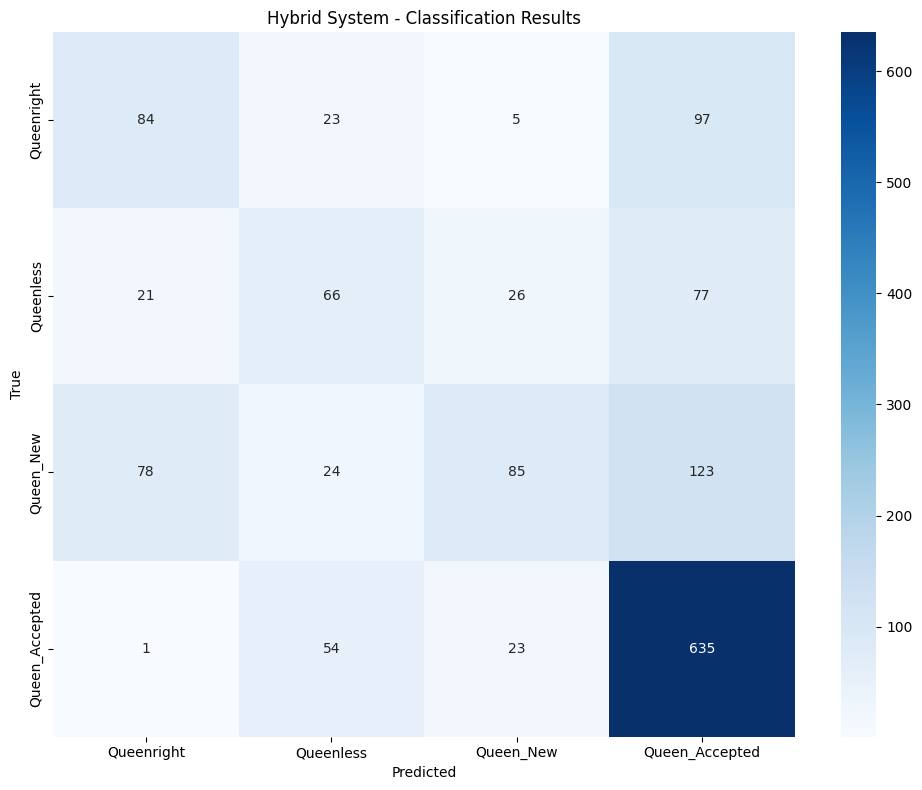

In [7]:
# Classification performance
y_true = results_df['true_label'].values
y_pred = results_df['classifier_class'].values

print("\nClassifier Performance:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=[CLASS_NAMES[i] for i in range(4)]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CLASS_NAMES[i] for i in range(4)],
            yticklabels=[CLASS_NAMES[i] for i in range(4)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Hybrid System - Classification Results')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hybrid_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



Hybrid Decision Distribution:
final_decision
KNOWN_ANOMALY      1416
UNKNOWN_ANOMALY       3
NORMAL                3
Name: count, dtype: int64


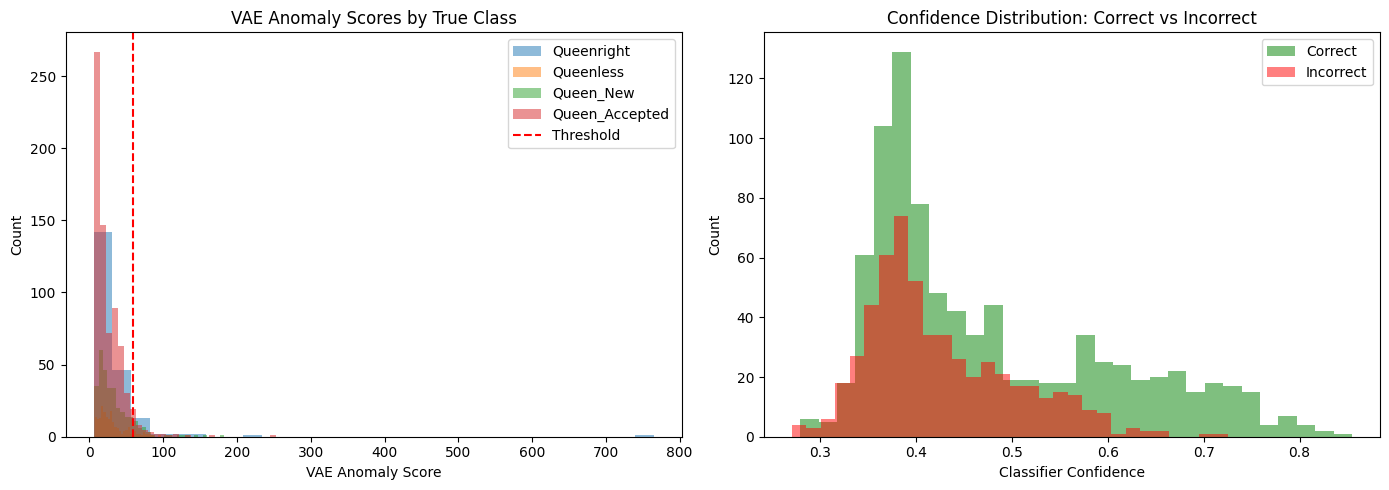

In [8]:
# Hybrid decision analysis
print("\nHybrid Decision Distribution:")
print(results_df['final_decision'].value_counts())

# VAE anomaly detection by true class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VAE scores by class
ax1 = axes[0]
for label in sorted(results_df['true_label'].unique()):
    subset = results_df[results_df['true_label'] == label]
    ax1.hist(subset['vae_anomaly_score'], bins=30, alpha=0.5, label=CLASS_NAMES[label])
ax1.axvline(vae_threshold, color='r', linestyle='--', label='Threshold')
ax1.set_xlabel('VAE Anomaly Score')
ax1.set_ylabel('Count')
ax1.set_title('VAE Anomaly Scores by True Class')
ax1.legend()

# Confidence by correctness
ax2 = axes[1]
results_df['is_correct'] = (results_df['classifier_class'] == results_df['true_label'])
correct = results_df[results_df['is_correct']]['classifier_confidence']
incorrect = results_df[~results_df['is_correct']]['classifier_confidence']
ax2.hist(correct, bins=30, alpha=0.5, label='Correct', color='green')
ax2.hist(incorrect, bins=30, alpha=0.5, label='Incorrect', color='red')
ax2.set_xlabel('Classifier Confidence')
ax2.set_ylabel('Count')
ax2.set_title('Confidence Distribution: Correct vs Incorrect')
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hybrid_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Summary


In [9]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

print("=" * 60)
print("BUZZHIVE HYBRID ANOMALY DETECTION SYSTEM - SUMMARY")
print("=" * 60)

print("\n1. CNN CLASSIFIER (Known Anomalies)")
print(f"   - Architecture: 4-layer CNN on mel-spectrograms")
print(f"   - Classes: {list(CLASS_NAMES.values())}")
print(f"   - Test Accuracy: {accuracy:.4f}")
print(f"   - Test F1 (weighted): {f1:.4f}")

print("\n2. VAE ANOMALY DETECTOR (Unknown Anomalies)")
print(f"   - Architecture: 1D Conv VAE on MFCCs")
print(f"   - Latent dimension: {vae_checkpoint['latent_dim']}")
print(f"   - Detection threshold: {vae_threshold:.4f}")
print(f"   - ROC-AUC: {vae_checkpoint['roc_auc']:.4f}")

print("\n3. HYBRID DECISION LOGIC")
print("   - If classifier confident normal + VAE detects anomaly => UNKNOWN_ANOMALY")
print("   - If classifier detects anomaly class => KNOWN_ANOMALY")
print("   - Otherwise => NORMAL")

print("\n4. TEST SET RESULTS")
print(f"   - Total samples: {len(results_df)}")
print(f"   - Normal predictions: {(results_df['final_decision'] == 'NORMAL').sum()}")
print(f"   - Known anomalies: {(results_df['final_decision'] == 'KNOWN_ANOMALY').sum()}")
print(f"   - Unknown anomalies: {(results_df['final_decision'] == 'UNKNOWN_ANOMALY').sum()}")

print("\n5. SAVED MODELS")
print(f"   - {MODEL_DIR / 'beehive_cnn_classifier.pth'}")
print(f"   - {MODEL_DIR / 'beehive_vae_anomaly.pth'}")


BUZZHIVE HYBRID ANOMALY DETECTION SYSTEM - SUMMARY

1. CNN CLASSIFIER (Known Anomalies)
   - Architecture: 4-layer CNN on mel-spectrograms
   - Classes: ['Queenright', 'Queenless', 'Queen_New', 'Queen_Accepted']
   - Test Accuracy: 0.6118
   - Test F1 (weighted): 0.5819

2. VAE ANOMALY DETECTOR (Unknown Anomalies)
   - Architecture: 1D Conv VAE on MFCCs
   - Latent dimension: 16
   - Detection threshold: 59.0176
   - ROC-AUC: 0.6117

3. HYBRID DECISION LOGIC
   - If classifier confident normal + VAE detects anomaly => UNKNOWN_ANOMALY
   - If classifier detects anomaly class => KNOWN_ANOMALY
   - Otherwise => NORMAL

4. TEST SET RESULTS
   - Total samples: 1422
   - Normal predictions: 3
   - Known anomalies: 1416
   - Unknown anomalies: 3

5. SAVED MODELS
   - ../outputs/models/beehive_cnn_classifier.pth
   - ../outputs/models/beehive_vae_anomaly.pth
